**MCE and Support Vector Machines (SVMs)** ###

This project focuses on the learning of different numbers using the training data of two digits ('1' and '7') to learn MCE and two binary SVM classifiers i) MCE, ii) a linear SVM; and ii) a nonlinear SVM with Gaussian RBF kernel

MNIST loaded:
train: (60000, 784) (60000,)
test : (10000, 784) (10000,)

Binary dataset 1 vs 7
train: (13007, 784) (13007,)
test : (2163, 784) (2163,)

Best MCE config: {'lr': 0.01, 'epochs': 20, 'batch_size': 128, 'lam': 0.0001}

Best MCE (1 vs 7)
accuracy   : 0.9889
train time : 0.6953 sec


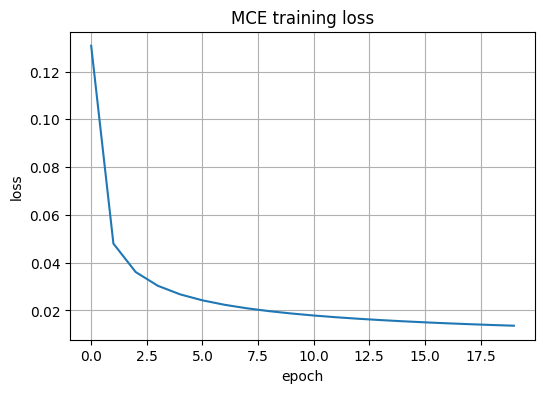

In [ ]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------------------------------
# Load MNIST
# -------------------------------------------------
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X_all = mnist.data.astype(np.float32) / 255.0
y_all = mnist.target.astype(int)

# official MNIST split
X_train_all = X_all[:60000]
y_train_all = y_all[:60000]
X_test_all  = X_all[60000:]
y_test_all  = y_all[60000:]

print("MNIST loaded:")
print("train:", X_train_all.shape, y_train_all.shape)
print("test :", X_test_all.shape, y_test_all.shape)


# -------------------------------------------------
# Helper functions
# -------------------------------------------------
def filter_digits(X, y, digits):
    mask = np.isin(y, digits)
    return X[mask], y[mask]

def prepare_binary_digits(X_train, y_train, X_test, y_test, d1=1, d2=7):
    Xtr, ytr = filter_digits(X_train, y_train, [d1, d2])
    Xte, yte = filter_digits(X_test, y_test, [d1, d2])

    # labels for MCE/SVM binary classification
    ytr_bin = np.where(ytr == d1, -1, 1).astype(np.float32)
    yte_bin = np.where(yte == d1, -1, 1).astype(np.float32)

    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    return Xtr_s, ytr_bin, Xte_s, yte_bin, ytr, yte

def report_result(name, y_true, y_pred, train_time, extra=None):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"accuracy   : {acc:.4f}")
    print(f"train time : {train_time:.4f} sec")
    if extra is not None:
        print(extra)
    return acc


# MCE implementation with mini-batch gradient descent
# Binary labels must be {-1, +1}
class MCEBinaryClassifier:
    def __init__(self, lr=0.01, epochs=30, batch_size=256, lam=1e-4, seed=42):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.lam = lam
        self.seed = seed
        self.w = None
        self.b = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        n, d = X.shape
        self.w = np.zeros(d, dtype=np.float32)
        self.b = 0.0

        for epoch in range(self.epochs):
            idx = rng.permutation(n)
            Xs = X[idx]
            ys = y[idx]

            epoch_loss = 0.0

            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                xb = Xs[start:end]
                yb = ys[start:end]

                scores = xb @ self.w + self.b
                margins = yb * scores

                # MCE-style smooth loss: sigmoid(-margin)
                probs = self._sigmoid(-margins)
                loss = np.mean(probs) + 0.5 * self.lam * np.sum(self.w ** 2)
                epoch_loss += loss * len(xb)

                # gradient
                # d sigmoid(-m)/dm = -sigmoid(-m)*(1-sigmoid(-m))
                coeff = -(probs * (1.0 - probs)) * yb
                grad_w = np.mean(coeff[:, None] * xb, axis=0) + self.lam * self.w
                grad_b = np.mean(coeff)

                self.w -= self.lr * grad_w
                self.b -= self.lr * grad_b

            epoch_loss /= n
            self.loss_history.append(epoch_loss)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        s = self.decision_function(X)
        return np.where(s >= 0, 1, -1).astype(np.float32)


# Q1.1: Binary 1 vs 7
Xtr, ytr_bin, Xte, yte_bin, ytr_digits, yte_digits = prepare_binary_digits(
    X_train_all, y_train_all, X_test_all, y_test_all, d1=1, d2=7
)

print("\nBinary dataset 1 vs 7")
print("train:", Xtr.shape, ytr_bin.shape)
print("test :", Xte.shape, yte_bin.shape)

# MCE hyperparameter search
mce_grid = {
    "lr": [0.01, 0.005],
    "epochs": [20, 30],
    "batch_size": [128, 256],
    "lam": [1e-4, 1e-3]
}

best_mce = None
best_mce_acc = -1
best_mce_cfg = None
best_mce_time = None

for lr, epochs, batch_size, lam in itertools.product(
    mce_grid["lr"], mce_grid["epochs"], mce_grid["batch_size"], mce_grid["lam"]
):
    model = MCEBinaryClassifier(lr=lr, epochs=epochs, batch_size=batch_size, lam=lam, seed=42)
    t0 = time.time()
    model.fit(Xtr, ytr_bin)
    t1 = time.time()

    pred = model.predict(Xte)
    acc = accuracy_score(yte_bin, pred)

    if acc > best_mce_acc:
        best_mce_acc = acc
        best_mce = model
        best_mce_cfg = {"lr": lr, "epochs": epochs, "batch_size": batch_size, "lam": lam}
        best_mce_time = t1 - t0

print("\nBest MCE config:", best_mce_cfg)
mce_pred = best_mce.predict(Xte)
report_result("Best MCE (1 vs 7)", yte_bin, mce_pred, best_mce_time)

# plot MCE loss
plt.figure(figsize=(6,4))
plt.plot(best_mce.loss_history)
plt.title("MCE training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.show()

In [ ]:
# ---------- Linear SVM ----------
# Define the range of C values to search for hyperparameter tuning
linear_C_values = [0.01, 0.1, 1, 10]

# Initialize variables to store the best model, its accuracy, C value, and training time
best_linear = None
best_linear_acc = -1
best_linear_C = None
best_linear_time = None

# Iterate through each C value to find the best linear SVM model
for C in linear_C_values:
    # Initialize LinearSVC with the current C value
    # max_iter is set for convergence, dual=False is preferred for n_samples > n_features
    clf = LinearSVC(C=C, max_iter=5000, dual=False)
    t0 = time.time()
    # Train the Linear SVM model on the training data
    clf.fit(Xtr, ytr_bin)
    t1 = time.time()
    # Make predictions on the test data
    pred = clf.predict(Xte)
    # Calculate the accuracy of the current model
    acc = accuracy_score(yte_bin, pred)

    # Check if the current model has a better accuracy than the previously best model
    if acc > best_linear_acc:
        best_linear_acc = acc
        best_linear = clf
        best_linear_C = C
        best_linear_time = t1 - t0

# Print the best C value found during hyperparameter search
print("\nBest Linear SVM C:", best_linear_C)
# Use the best model to make predictions on the test set
linear_pred = best_linear.predict(Xte)
# Report the results (accuracy and training time) of the best linear SVM
report_result("Best Linear SVM (1 vs 7)", yte_bin, linear_pred, best_linear_time)



Best Linear SVM C: 0.01

Best Linear SVM (1 vs 7)
accuracy   : 0.9940
train time : 2.2734 sec


0.9939898289412853

In [ ]:
# ---------- RBF SVM ----------
# Due to the computational cost of RBF SVMs, especially with hyperparameter tuning,
# a subset of the training data is used for efficiency.
rng = np.random.default_rng(42)
subset_size = 4000

if len(Xtr) > subset_size:
    idx = rng.choice(len(Xtr), size=subset_size, replace=False)
    Xtr_rbf = Xtr[idx]
    ytr_rbf = ytr_bin[idx]
else:
    Xtr_rbf = Xtr
    ytr_rbf = ytr_bin

# Define hyperparameter grids for C and gamma for the RBF kernel SVM.
# C controls the penalty for misclassification, and gamma defines the influence of a single training example.
rbf_C_values = [1, 10]
rbf_gamma_values = ["scale", 0.01]

best_rbf = None
best_rbf_acc = -1
best_rbf_cfg = None
best_rbf_time = None

print("\nTraining RBF SVMs...")
print("RBF subset shape:", Xtr_rbf.shape, ytr_rbf.shape)

# Perform a grid search over the defined C and gamma values.
# For each combination, a new SVC model with an RBF kernel is trained and evaluated.
for C, gamma in itertools.product(rbf_C_values, rbf_gamma_values):
    print(f"Trying C={C}, gamma={gamma}...")
    clf = SVC(kernel="rbf", C=C, gamma=gamma, cache_size=1000)
    t0 = time.time()
    clf.fit(Xtr_rbf, ytr_rbf)
    t1 = time.time()

    # Evaluate the model on the test set and keep track of the best performing configuration.
    pred = clf.predict(Xte)
    acc = accuracy_score(yte_bin, pred)
    print(f"Done: acc={acc:.4f}, time={t1-t0:.4f}s")

    if acc > best_rbf_acc:
        best_rbf_acc = acc
        best_rbf = clf
        best_rbf_cfg = {"C": C, "gamma": gamma}
        best_rbf_time = t1 - t0

# After the grid search, report the performance of the best RBF SVM model.
print("\nBest RBF SVM config:", best_rbf_cfg)
rbf_pred = best_rbf.predict(Xte)
report_result("Best RBF SVM (1 vs 7)", yte_bin, rbf_pred, best_rbf_time)

# Summarize the best accuracy and training time for MCE, Linear SVM, and RBF SVM
# for a comparative analysis of their performance.
print(f"MCE best acc        = {best_mce_acc:.4f}, time = {best_mce_time:.4f}s, cfg = {best_mce_cfg}")
print(f"Linear SVM best acc = {best_linear_acc:.4f}, time = {best_linear_time:.4f}s, C = {best_linear_C}")
print(f"RBF SVM best acc    = {best_rbf_acc:.4f}, time = {best_rbf_time:.4f}s, cfg = {best_rbf_cfg}")

print("\nConfusion matrix for best RBF SVM:")
print(confusion_matrix(yte_bin, rbf_pred))



Training RBF SVMs...
RBF subset shape: (4000, 784) (4000,)
Trying C=1, gamma=scale...
Done: acc=0.9871, time=1.0445s
Trying C=1, gamma=0.01...
Done: acc=0.9616, time=3.5141s
Trying C=10, gamma=scale...
Done: acc=0.9903, time=1.2618s
Trying C=10, gamma=0.01...
Done: acc=0.9663, time=5.0878s

Best RBF SVM config: {'C': 10, 'gamma': 'scale'}

Best RBF SVM (1 vs 7)
accuracy   : 0.9903
train time : 1.2618 sec
MCE best acc        = 0.9889, time = 0.6953s, cfg = {'lr': 0.01, 'epochs': 20, 'batch_size': 128, 'lam': 0.0001}
Linear SVM best acc = 0.9940, time = 2.2734s, C = 0.01
RBF SVM best acc    = 0.9903, time = 1.2618s, cfg = {'C': 10, 'gamma': 'scale'}

Confusion matrix for best RBF SVM:
[[1118   17]
 [   4 1024]]


Implementation of the majority voting method (considering to use the one vs. one strategy) to extend binary RBF nonlinear SVM classifier to a multi-class classifier using all training data of 5 digits ('1', '5', '7', '8', and '9') in MNIST to learn a 5-class classifier. Performance in the held-out test set of these 5 digits.

In [ ]:
# Define the 5 digits to be used for multi-class classification.
digits_5 = [1, 5, 7, 8, 9]

# Filter the MNIST dataset to include only the selected 5 digits.
Xtr5, ytr5 = filter_digits(X_train_all, y_train_all, digits_5)
Xte5, yte5 = filter_digits(X_test_all, y_test_all, digits_5)

# Scale the features using StandardScaler for optimal SVM performance.
scaler5 = StandardScaler()
Xtr5 = scaler5.fit_transform(Xtr5)
Xte5 = scaler5.transform(Xte5)

print("\n5-class dataset")
print("train:", Xtr5.shape, ytr5.shape)
print("test :", Xte5.shape, yte5.shape)

# Use a subset of the training data for faster experimentation with RBF SVMs,
# especially given the 'one vs. one' strategy which trains multiple classifiers.
rng = np.random.default_rng(42)
subset_size_5 = 8000

if len(Xtr5) > subset_size_5:
    idx5 = rng.choice(len(Xtr5), size=subset_size_5, replace=False)
    Xtr5_sub = Xtr5[idx5]
    ytr5_sub = ytr5[idx5]
else:
    Xtr5_sub = Xtr5
    ytr5_sub = ytr5

print("5-class RBF subset:", Xtr5_sub.shape, ytr5_sub.shape)

# Implement a One-vs-One (OVO) strategy for multi-class classification using RBF SVMs.
# This involves training a binary SVM for every possible pair of classes.
class OneVsOneRBF:
    def __init__(self, C=10, gamma="scale"):
        self.C = C
        self.gamma = gamma
        self.models = {}
        self.classes_ = None

    # The fit method trains a binary RBF SVM for each unique pair of classes.
    # For each pair (a, b), data belonging to 'a' is labeled -1 and 'b' is labeled 1.
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for a, b in itertools.combinations(self.classes_, 2):
            print(f"  training pair ({a}, {b})")
            mask = np.isin(y, [a, b])
            X_pair = X[mask]
            y_pair = y[mask]
            y_pair_bin = np.where(y_pair == a, -1, 1)

            clf = SVC(kernel="rbf", C=self.C, gamma=self.gamma, cache_size=1000)
            clf.fit(X_pair, y_pair_bin)
            self.models[(a, b)] = clf
        return self

    # The predict method uses a majority voting scheme to classify new instances.
    # Each binary SVM 'votes' for one of its two classes, and the class with the most votes wins.
    def predict(self, X):
        n = X.shape[0]
        classes = list(self.classes_)
        class_to_idx = {c: i for i, c in enumerate(classes)}
        votes = np.zeros((n, len(classes)), dtype=int)

        for (a, b), clf in self.models.items():
            p = clf.predict(X)  # vectorized prediction
            votes[:, class_to_idx[a]] += (p == -1)
            votes[:, class_to_idx[b]] += (p == 1)

        pred_idx = np.argmax(votes, axis=1)
        return np.array([classes[i] for i in pred_idx])

# Define the hyperparameters for the One-vs-One RBF SVM.
# These parameters are chosen after considering initial experiments and computational cost.
ovo_C_values = [10]
ovo_gamma_values = ["scale"]

best_ovo = None
best_ovo_acc = -1
best_ovo_cfg = None
best_ovo_time = None

# Train and evaluate the One-vs-One RBF SVM classifier.
# Given the training time for multiple SVMs, a smaller set of hyperparameters is explored.
for C, gamma in itertools.product(ovo_C_values, ovo_gamma_values):
    print(f"\nTraining OVO RBF with C={C}, gamma={gamma}...")
    clf = OneVsOneRBF(C=C, gamma=gamma)
    t0 = time.time()
    clf.fit(Xtr5_sub, ytr5_sub)
    pred = clf.predict(Xte5)
    t1 = time.time()

    acc = accuracy_score(yte5, pred)
    print(f"C={C}, gamma={gamma}, acc={acc:.4f}, time={t1-t0:.4f}s")

    if acc > best_ovo_acc:
        best_ovo_acc = acc
        best_ovo = clf
        best_ovo_cfg = {"C": C, "gamma": gamma}
        best_ovo_time = t1 - t0

# Report the performance of the best One-vs-One RBF SVM model, including accuracy and training time.
print("\nBest OVO RBF config:", best_ovo_cfg)
ovo_pred = best_ovo.predict(Xte5)
report_result("Q1.2 OVO RBF SVM (1,5,7,8,9)", yte5, ovo_pred, best_ovo_time)

# Provide a detailed classification report and confusion matrix to further analyze the model's performance
# across individual classes and identify any misclassifications.
print("\nClassification report:")
print(classification_report(yte5, ovo_pred))

print("\nConfusion matrix:")
print(confusion_matrix(yte5, ovo_pred))



5-class dataset
train: (30228, 784) (30228,)
test : (5038, 784) (5038,)
5-class RBF subset: (8000, 784) (8000,)

Training OVO RBF with C=10, gamma=scale...
  training pair (1, 5)
  training pair (1, 7)
  training pair (1, 8)
  training pair (1, 9)
  training pair (5, 7)
  training pair (5, 8)
  training pair (5, 9)
  training pair (7, 8)
  training pair (7, 9)
  training pair (8, 9)
C=10, gamma=scale, acc=0.9671, time=30.2120s

Best OVO RBF config: {'C': 10, 'gamma': 'scale'}

Q1.2 OVO RBF SVM (1,5,7,8,9)
accuracy   : 0.9671
train time : 30.2120 sec

Classification report:
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1135
           5       0.96      0.97      0.97       892
           7       0.94      0.97      0.95      1028
           8       0.97      0.96      0.96       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97      5038
   macro avg       0.97      0.97      